# Análise exploratória — Medical Abstracts TC Corpus

Este notebook explora o corpus usado para treinar o classificador de
triagem e reproduz, com as funções de `src/triage`, a comparação de
candidatos e a avaliação do modelo escolhido. Nenhuma lógica de
carregamento, treino ou avaliação é reimplementada aqui — todas as células
chamam funções de `triage.*`.

**Disclaimer**: o corpus é composto de abstracts científicos em inglês, não
de laudos hospitalares reais; e o mapa de urgência usado no serviço é uma
heurística de produto, não um rótulo clínico validado (ver
`docs/model_card.md`).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

from triage.config.seeds import SEED, set_seed
from triage.data.loader import load_split, train_val_split
from triage.data.schema import CONDITION_NAMES, LABELS
from triage.features.text import build_vectorizer
from triage.models.evaluate import evaluate
from triage.models.train import run_experiments, train

set_seed()
sns.set_theme(style="whitegrid")
DATA_DIR = Path.cwd().parent / "data"


## Carga do corpus

Carga e limpeza via `triage.data.loader.load_split` — a mesma função usada em treino e na DAG do Airflow.

In [2]:
train_df = load_split("train", data_dir=DATA_DIR)
test_df = load_split("test", data_dir=DATA_DIR)

print(f"treino: {len(train_df)} documentos")
print(f"teste (held-out): {len(test_df)} documentos")
train_df.head()


treino: 9445 documentos
teste (held-out): 2770 documentos


,condition_label,medical_abstract
0,5,Tissue changes around loose prostheses. A cani...
1,1,Neuropeptide Y and neuron-specific enolase lev...
2,2,"Sexually transmitted diseases of the colon, re..."
3,1,Lipolytic factors associated with murine and h...
4,3,Does carotid restenosis predict an increased r...


## Distribuição das 5 classes

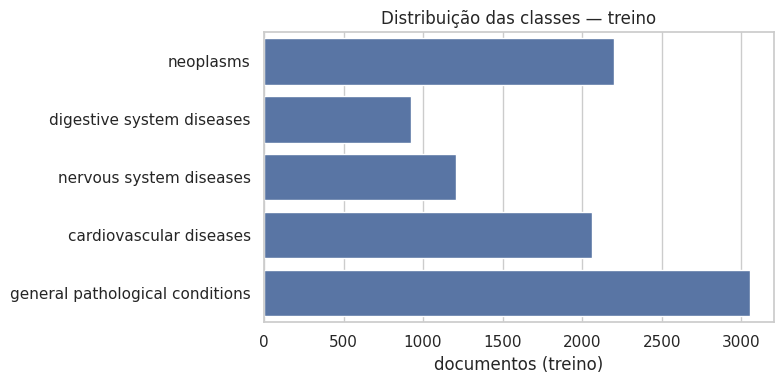

condition_label
neoplasms                          2200
digestive system diseases           927
nervous system diseases            1206
cardiovascular diseases            2059
general pathological conditions    3053
Name: count, dtype: int64

In [3]:
counts = (
    train_df["condition_label"]
    .map(CONDITION_NAMES)
    .value_counts()
    .reindex([CONDITION_NAMES[label] for label in LABELS])
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#4C72B0")
ax.set_xlabel("documentos (treino)")
ax.set_ylabel("")
ax.set_title("Distribuição das classes — treino")
fig.tight_layout()
plt.show()
counts


A classe `general pathological conditions` é a mais numerosa e, como a
avaliação do modelo mostra mais adiante, também a mais difícil de separar
das demais — consistente com ser um agrupamento mais heterogêneo de
condições.

## Distribuição do comprimento dos abstracts

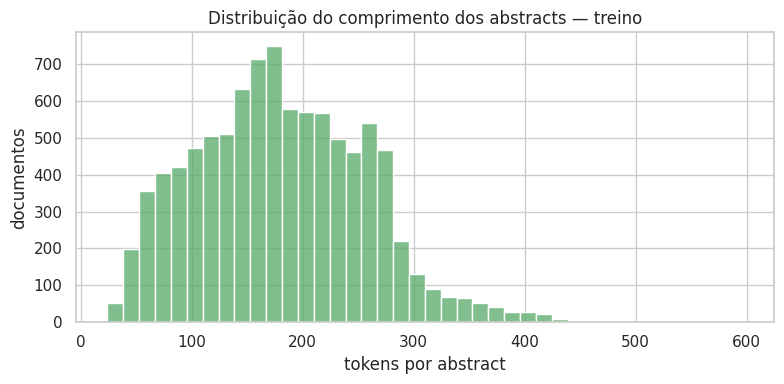

count    9445.000000
mean      180.156379
std        76.269120
min        24.000000
25%       123.000000
50%       176.000000
75%       235.000000
max       596.000000
Name: medical_abstract, dtype: float64

In [4]:
lengths = train_df["medical_abstract"].str.split().map(len)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(lengths, bins=40, ax=ax, color="#55A868")
ax.set_xlabel("tokens por abstract")
ax.set_ylabel("documentos")
ax.set_title("Distribuição do comprimento dos abstracts — treino")
fig.tight_layout()
plt.show()
lengths.describe()


## Termos mais frequentes por classe

Reaproveita `triage.features.text.build_vectorizer` — o mesmo vetorizador
usado no pipeline de treino e de inferência — para não duplicar nenhuma
lógica de tokenização/normalização de texto.

O TF-IDF bruto por média, sem `stop_words`, é dominado por palavras funcionais do inglês (`the`, `of`, `with`, `was`...) — `stop_words` foi removido do vetorizador (`triage.features.text.build_vectorizer`) para manter o pipeline conversível para ONNX (ver `docs/latency_report.md` e `scripts/export_onnx.py`), e sem essa filtragem os termos de maior TF-IDF médio deixam de ser discriminativos. Por isso o ranking abaixo usa um escore discriminativo — TF-IDF médio dentro da classe menos TF-IDF médio fora dela — em vez do TF-IDF médio bruto. Os nomes de termo também precisam ser reconstituídos: `TraceableTfidfVectorizer` (usado no lugar do `TfidfVectorizer` comum, ver docstring de `build_vectorizer`) devolve cada n-grama como uma tupla de tokens, não como uma única string.

In [5]:
vectorizer = build_vectorizer(min_df=5)
tfidf_matrix = vectorizer.fit_transform(train_df["medical_abstract"])
feature_names = vectorizer.get_feature_names_out()
vocabulary = np.array(
    [" ".join(t) if isinstance(t, tuple) else t for t in feature_names]
)

top_terms_by_class = {}
for label in LABELS:
    mask = (train_df["condition_label"] == label).to_numpy()
    mean_in_class = np.asarray(tfidf_matrix[mask].mean(axis=0)).ravel()
    mean_outside_class = np.asarray(tfidf_matrix[~mask].mean(axis=0)).ravel()
    discriminative_score = mean_in_class - mean_outside_class
    top_indices = discriminative_score.argsort()[::-1][:10]
    top_terms_by_class[CONDITION_NAMES[label]] = list(vocabulary[top_indices])

pd.DataFrame(top_terms_by_class)


,neoplasms,digestive system diseases,nervous system diseases,cardiovascular diseases,general pathological conditions
0,cancer,liver,brain,coronary,postoperative
1,tumor,gastric,cerebral,pressure,infection
2,carcinoma,biliary,pain,ventricular,chronic
3,cell,bowel,nerve,heart,acute
4,tumors,esophageal,seizures,myocardial,complications
5,cells,hepatitis,motor,artery,children
6,malignant,cirrhosis,headache,hypertension,respiratory
7,breast,gallbladder,syndrome,left,injury
8,cell carcinoma,ulcer,stroke,cardiac,infections
9,survival,endoscopic,spinal,blood pressure,recurrent


## Comparação de modelos candidatos

Via `triage.models.train.run_experiments` — a mesma função usada por
`scripts/train.py --compare` e cujos resultados constam em
`docs/model_card.md`.

In [6]:
fit_train_df, val_df = train_val_split(train_df, val_size=0.2, seed=SEED)

comparison = run_experiments(
    fit_train_df,
    val_df,
    model_names=["logistic_regression", "linear_svc", "naive_bayes", "dummy"],
)
pd.DataFrame(comparison)[["model_name", "macro_f1", "accuracy", "fit_seconds"]]


,model_name,macro_f1,accuracy,fit_seconds
0,logistic_regression,0.684705,0.686607,9.367702
1,linear_svc,0.684280,0.694018,6.868877
2,naive_bayes,0.404303,0.566967,6.034690
3,dummy,0.097760,0.323452,6.296837


`logistic_regression` e `linear_svc` empatam tecnicamente; `logistic_regression`
é o modelo escolhido para produção por ser o mais simples dos dois — sem a
camada extra de calibração que `linear_svc` precisa só para expor
`predict_proba` (ver `docs/model_card.md` para a discussão completa).

## Matriz de confusão do modelo escolhido, no held-out

Treina `logistic_regression` no treino completo (`fit_train_df` +
`val_df`) e avalia no held-out (`test_df`) via `triage.models.evaluate.evaluate`
— os mesmos números reportados em `docs/model_card.md`.

In [7]:
final_pipeline = train(
    train_df["medical_abstract"].tolist(),
    train_df["condition_label"].tolist(),
    "logistic_regression",
)
report = evaluate(
    final_pipeline,
    test_df["medical_abstract"].tolist(),
    test_df["condition_label"].tolist(),
)
print(f"macro-F1 (held-out): {report['macro_f1']:.4f}")
print(f"acurácia (held-out): {report['accuracy']:.4f}")
pd.DataFrame(report["per_class"]).T


macro-F1 (held-out): 0.5900
acurácia (held-out): 0.5874


,precision,recall,f1,support
neoplasms,0.679525,0.743506,0.710078,616.0
digestive system diseases,0.485488,0.641115,0.552553,287.0
nervous system diseases,0.525959,0.636612,0.576020,366.0
cardiovascular diseases,0.652842,0.721562,0.685484,589.0
general pathological conditions,0.524880,0.358553,0.426059,912.0


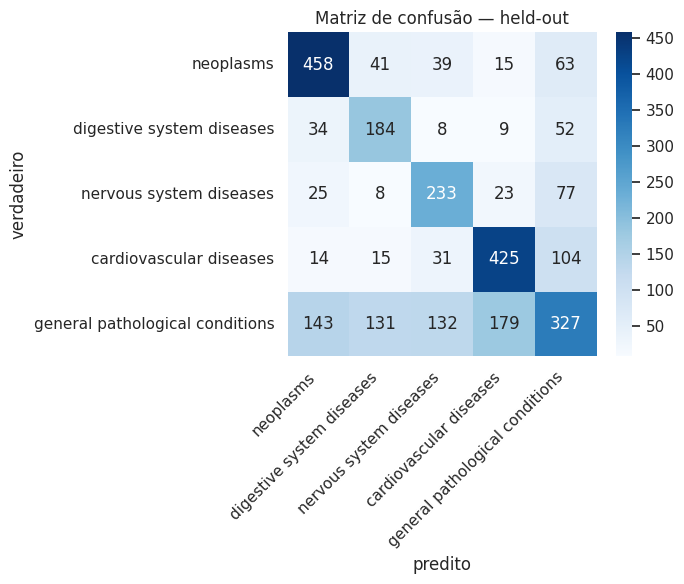

In [8]:
labels_order = [CONDITION_NAMES[label] for label in LABELS]
cm = np.array(report["confusion_matrix"])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_order,
    yticklabels=labels_order,
    ax=ax,
)
ax.set_xlabel("predito")
ax.set_ylabel("verdadeiro")
ax.set_title("Matriz de confusão — held-out")
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()


A classe `general pathological conditions` concentra a maior parte dos
erros de classificação cruzada — consistente com a hipótese de que é a
categoria mais heterogênea e, portanto, a mais difícil de separar
linearmente das demais. Ver `docs/model_card.md` para a discussão de
limitações e de custo/benefício da otimização ONNX aplicada
posteriormente a este pipeline.